# Xpansion performance

Antares Xpansion performance has been improved throughout the versions.
Here is a presentation across several reference studies.

## Presentation of the reference studies

The following table describes the characteristics of the reference studies :
- `areas` : number of areas in the study
- `links` : number of links in the study
- `master.candidates` : number of investment candidates
- `master_type` : type of the master problem
- `subproblems.variables` : number of variables in a single weekly subproblem
- `subproblems.constraints` : number of constraints in a single weekly subproblem
- `subproblems.non_zero_coefficients` : number of non-zero coefficients in the matrix of a single weekly subproblem
- `mc_years` : number of Monte-Carlo years used for the investment study
- `weeks` : number of weeks considered in each year
- `resolution.stopping_criterion.type` : stopping criterion type
- `resolution.stopping_criterion.value` : value of the stopping criterion

The number of subproblems at each iteration is `mc_years` $\times$ `weeks`.

In [4]:
import json
import pandas as pd

def load_perf_data(filepath: str) -> pd.DataFrame:
    with open(filepath) as f:
        json_data = json.load(f)
    df = pd.json_normalize(
        json_data["studies"],
        record_path=["xpansion_data"],
        meta=[
            "display_name", "areas", "links",
            ["master", "candidates"], ["master", "type"],
            ["subproblems", "variables"], ["subproblems", "constraints"],
            ["subproblems", "non_zero_coefficients"],
            ["mc_years"], ["weeks"],
            ["resolution", "stopping_criterion", "type"],
            ["resolution", "stopping_criterion", "value"],
        ],
    )
    return df.set_index(["display_name", "version"])

df = load_perf_data("../assets/graph-data/xpansion-performance-data.json")
columns_to_display = [
    "areas", "links",
    "master.candidates", "master.type",
    "subproblems.variables", "subproblems.constraints", "subproblems.non_zero_coefficients",
    "mc_years", "weeks",
    "resolution.stopping_criterion.type", "resolution.stopping_criterion.value",
]
stylized = df.loc[(slice(None), 1.1), columns_to_display].droplevel(1)
stylized

,areas,links,master.candidates,master.type,subproblems.variables,subproblems.constraints,subproblems.non_zero_coefficients,mc_years,weeks,resolution.stopping_criterion.type,resolution.stopping_criterion.value
display_name,,,,,,,,,,,
Study 1,61,398,112,integer,197736,78166,9904028,10,52,relative_gap,0.000001
Study 2,61,398,112,relaxed,197736,78166,9904028,10,52,relative_gap,0.000001
Study 3,61,398,112,relaxed,198072,78166,9945020,10,52,absolute_gap,1000000.0
Study 4,160,563,325,integer,278040,83249,27045279,10,52,relative_gap,0.000001


## Simulation time evolution

The graphs show the performance of several versions of Antares Xpansion on the studies presented above.

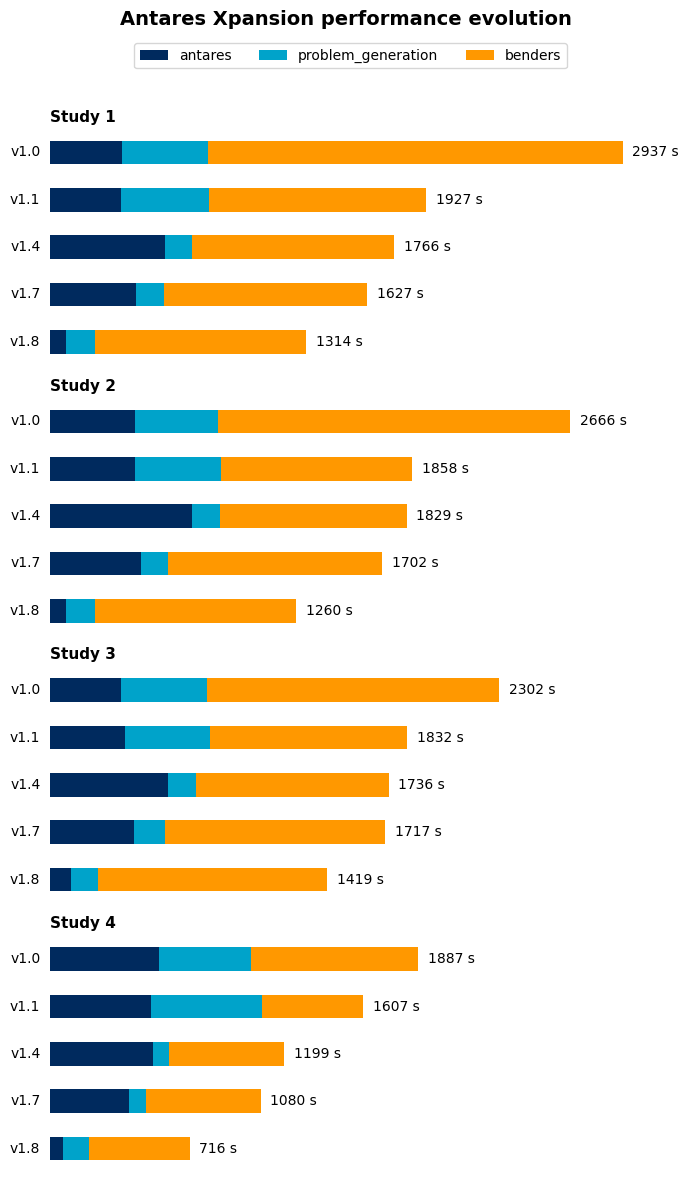

In [8]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

STEPS = ["antares", "problem_generation", "benders"]
COLORS = ["#002a5e", "#00a3ca", "#ff9800"]

with open("../assets/graph-data/xpansion-performance-data.json") as f:
    data = json.load(f)

studies = data["studies"]
n = len(studies)

fig, axes = plt.subplots(n, 1, figsize=(7, n * 3), sharex=True)

for ax, study in zip(axes, studies):
    versions = study["xpansion_data"]

    for i, v in enumerate(v for v in versions if v["version"] != 0.8):
        left = 0
        for step, color in zip(STEPS, COLORS):
            ax.barh(i, v[step], left=left, color=color, height=0.5)
            left += v[step]
        total = sum(v[step] for step in STEPS)

        # Version label on the left
        ax.text(-50, i, f"v{v['version']}", ha="right", va="center", fontsize=10)
        # Total label on the right
        ax.text(left + 50, i, f"{total} s", ha="left", va="center", fontsize=10)

    ax.set_yticks([])
    ax.set_title(study["display_name"], loc="left", fontsize=11, fontweight="bold")
    ax.xaxis.set_visible(False)
    ax.invert_yaxis()
    for spine in ax.spines.values():
        spine.set_visible(False)

axes[0].legend(STEPS, loc="upper center", ncol=3, fontsize=10,
               bbox_to_anchor=(0.5, 1.4))
fig.suptitle("Antares Xpansion performance evolution", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()